# Classification Problem


## Bank Marketing data - the marketing data is highly imbalance, so is subscription

## Loading Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
#uncomment this code for google colab
#from google.colab import files
#uploaded = files.upload()

In [240]:
bank_df = pd.read_excel('bank.xlsx')

In [241]:
#View some records from dataset 
bank_df.head(5)

,age,job,marital,education,default,balance,housing-loan,personal-loan,current-campaign,previous-campaign,subscribed
0,30,unemployed,married,primary,no,1787,no,no,1,0,no
1,33,services,married,secondary,no,4789,yes,yes,1,4,no
2,35,management,single,tertiary,no,1350,yes,no,1,1,no
3,30,management,married,tertiary,no,1476,yes,yes,4,0,no
4,59,blue-collar,married,secondary,no,0,yes,no,1,0,no


In [242]:
#Check dataset information 
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                4521 non-null   int64 
 1   job                4521 non-null   object
 2   marital            4521 non-null   object
 3   education          4521 non-null   object
 4   default            4521 non-null   object
 5   balance            4521 non-null   int64 
 6   housing-loan       4521 non-null   object
 7   personal-loan      4521 non-null   object
 8   current-campaign   4521 non-null   int64 
 9   previous-campaign  4521 non-null   int64 
 10  subscribed         4521 non-null   object
dtypes: int64(4), object(7)
memory usage: 388.7+ KB


In [243]:
#Check dataset information 
bank_df.shape

(4521, 11)

### Exercise:

- Build a logistic regression model with all the variables and left
- Compute RoC AUC and draw the curve
- Compute confusion and draw the confusion matrix

In [245]:
# Convert 'yes' to 1 and 'no' to 0
bank_df['subscribed'] = bank_df['subscribed'].map({'yes': 1, 'no': 0})

In [246]:
X = list(bank_df.columns)
X.remove('subscribed')

In [247]:
encoded_bank_df = pd.get_dummies(bank_df[X],drop_first = True)

In [248]:
X = encoded_bank_df
y = bank_df['subscribed']

In [292]:
X.shape

(4521, 23)

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [250]:
from sklearn.model_selection import train_test_split

In [251]:
X_train, X_test, y_train, y_test = train_test_split( X, y, 
                                                    test_size = 0.2, random_state = 42 )

In [288]:
#Check shape of Xtrain and Xtest
X_train.shape

(3616, 23)

In [290]:
X_test.shape

(905, 23)

### Build Logistic Regression Model

In [255]:
from sklearn.linear_model import LogisticRegression

In [256]:
logreg_v1 = LogisticRegression(random_state=100)

In [257]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [259]:
logreg_v1.intercept_

array([-0.39636788])

In [260]:
logreg_v1.coef_

array([[-1.22972580e-02, -1.04756413e-05, -1.13494536e-01,
         1.58448875e-01, -3.19886791e-01, -5.23880432e-02,
         7.57161039e-03,  7.47784981e-02,  2.52329130e-01,
        -6.65878776e-02, -1.24570562e-01,  1.26614033e-02,
        -1.37584921e-01, -3.73658304e-02,  2.21849561e-02,
        -3.72122214e-01, -1.49831523e-01, -2.91251348e-01,
         5.62843892e-02, -4.36426225e-02, -5.50015636e-03,
        -8.36622101e-01, -3.21418897e-01]])

### Predicting on Test Data

In [262]:
y_pred = logreg_v1.predict(X_test)

In [263]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [264]:
y_df.sample(10, random_state=20)

,actual,predicted
3807,0,0
2169,0,0
2203,0,0
3541,0,0
4443,0,0
957,0,0
2298,0,0
4096,0,0
3303,0,0
1058,0,0


### Measuring Accuracy

In [266]:
from sklearn.metrics import accuracy_score

In [267]:
accuracy_score(y_test, y_pred)

0.8939226519337017

In [268]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [269]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [270]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Subscribed', 'Not Subscribed'])

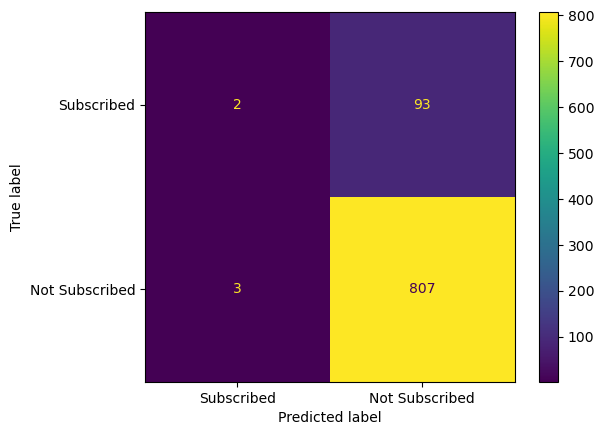

In [271]:
cm_plot.plot();

# Model is not great because FP is more - people leaving are not predicted correctly hence it is important

In [272]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [273]:
recall_score(y_df.actual, y_df.predicted)

0.021052631578947368

In [274]:
print(classification_report(y_df.actual, y_df.predicted))

# We only look at "1" value - here the recall is bad!

              precision    recall  f1-score   support

           0       0.90      1.00      0.94       810
           1       0.40      0.02      0.04        95

    accuracy                           0.89       905
   macro avg       0.65      0.51      0.49       905
weighted avg       0.84      0.89      0.85       905



## How to evaluate and compare models?

In [276]:
y_pred_probs = logreg_v1.predict_proba(X_test)

In [277]:
y_pred_probs[0:5]

array([[0.74827989, 0.25172011],
       [0.89960453, 0.10039547],
       [0.73765592, 0.26234408],
       [0.95810394, 0.04189606],
       [0.80132131, 0.19867869]])

In [278]:
y_pred_probs[:, 1]

array([0.25172011, 0.10039547, 0.26234408, 0.04189606, 0.19867869,
       0.29788136, 0.11231968, 0.0602513 , 0.19276604, 0.09506743,
       0.02155891, 0.14518873, 0.0856121 , 0.01460344, 0.35639145,
       0.05315314, 0.16016199, 0.12094395, 0.21734193, 0.07612487,
       0.06085618, 0.10536585, 0.21489448, 0.09620387, 0.08779752,
       0.17279283, 0.04829608, 0.12603059, 0.06723092, 0.05024949,
       0.0690497 , 0.18214942, 0.15743948, 0.20491041, 0.06058851,
       0.05310277, 0.06668239, 0.19409855, 0.25473468, 0.06479554,
       0.1429422 , 0.46230923, 0.14751491, 0.18099868, 0.0944045 ,
       0.0643953 , 0.16291911, 0.11553286, 0.06830278, 0.11878466,
       0.15712755, 0.03901205, 0.16687073, 0.14232381, 0.07211387,
       0.09806326, 0.18431752, 0.06914682, 0.11691887, 0.19882624,
       0.13997385, 0.06273071, 0.1986237 , 0.19308954, 0.04980723,
       0.09077188, 0.04666879, 0.13169659, 0.16248098, 0.07734203,
       0.16174924, 0.42541117, 0.04392753, 0.04878231, 0.02406

In [279]:
y_df['pred_probs'] = y_pred_probs[:, 1]

In [280]:
y_df.sample(10, random_state=20)

,actual,predicted,pred_probs
3807,0,0,0.061683
2169,0,0,0.169219
2203,0,0,0.229947
3541,0,0,0.208114
4443,0,0,0.271614
957,0,0,0.120075
2298,0,0,0.097792
4096,0,0,0.115133
3303,0,0,0.166309
1058,0,0,0.218831


### Finding the probability distribution of predicted probabilities

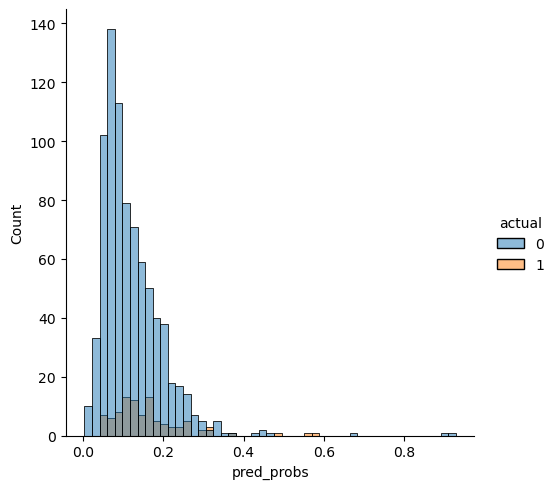

In [282]:
sn.displot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');

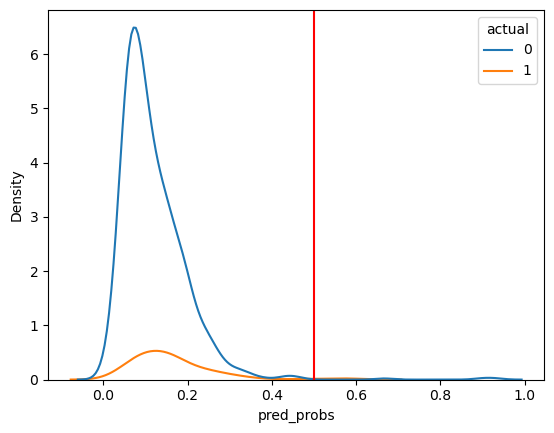

In [283]:
sn.kdeplot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');
plt.axvline(x = 0.5, color = 'r', label = 'cut off');

### What happens if we change the cutoff probabilities?

- What happens if cutoff probability is 0.0
- What happens if cutoff probability is 1.0

In [285]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [286]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.6541650422352177

AttributeError: 'RocCurveDisplay' object has no attribute 'plots'

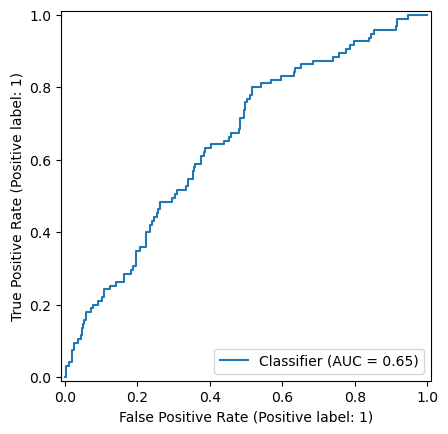

In [287]:
RocCurveDisplay.from_predictions(y_df.actual, y_df.pred_probs).plots();

### Changing the cutoff probabilities

In [294]:
y_df['new_preds'] = y_df.pred_probs.map(lambda x: 1 if x > 0.30 else 0)

In [296]:
cm_new = confusion_matrix(y_df.actual, y_df.new_preds, labels = [1,0])

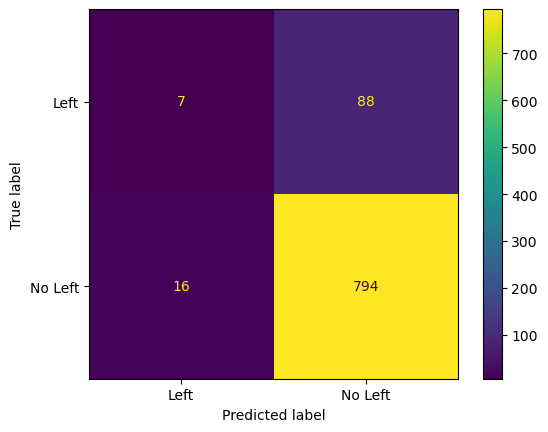

In [298]:
ConfusionMatrixDisplay(cm_new, display_labels=['Subscribed', 'Not Subscribed']).plot();

In [300]:
print(classification_report(y_df.actual, y_df.new_preds))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       810
           1       0.30      0.07      0.12        95

    accuracy                           0.89       905
   macro avg       0.60      0.53      0.53       905
weighted avg       0.84      0.89      0.85       905



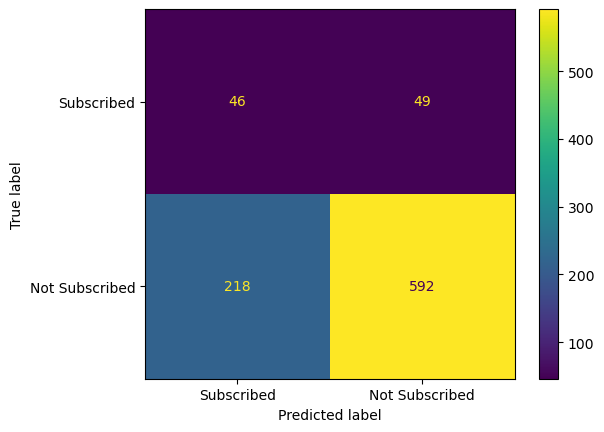

In [313]:
y_df['new_preds'] = y_df.pred_probs.map(lambda x: 1 if x > 0.15 else 0)
cm_new = confusion_matrix(y_df.actual, y_df.new_preds, labels = [1,0])
ConfusionMatrixDisplay(cm_new, display_labels=['Subscribed', 'Not Subscribed']).plot();

In [315]:
print(classification_report(y_df.actual, y_df.new_preds))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82       810
           1       0.17      0.48      0.26        95

    accuracy                           0.70       905
   macro avg       0.55      0.61      0.54       905
weighted avg       0.84      0.70      0.76       905

